# 03-1 K-최근접 이웃 회귀

## 4️⃣ 실습 데이터 준비

In [5]:
import numpy as np

perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

## 농어의 길이만 사용

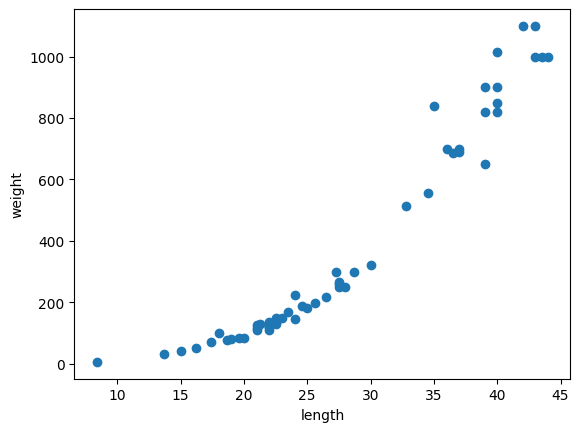

In [6]:
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

#훈련세트와 테스트세트 나누기
train_input, test_input, train_target, test_target = train_test_split(perch_length,
                                                                    perch_weight,
                                                                    random_state=42)

In [8]:
train_input

array([19.6, 22. , 18.7, 17.4, 36. , 25. , 40. , 39. , 43. , 22. , 20. ,
       22. , 24. , 27.5, 43. , 40. , 24. , 21. , 27.5, 40. , 32.8, 26.5,
       36.5, 13.7, 22.7, 15. , 37. , 35. , 28.7, 23.5, 39. , 21. , 23. ,
       22. , 44. , 22.5, 19. , 37. , 22. , 25.6, 42. , 34.5])

In [9]:
train_input.shape, test_input.shape

((42,), (14,))

In [10]:
test_array = np.array([1,2,3,4])
test_array.shape

(4,)

In [11]:
test_array = test_array.reshape(2,2)
test_array.shape

(2, 2)

In [12]:
test_array

array([[1, 2],
       [3, 4]])

In [13]:
# train_input, test_input 2차원으로
train_input = train_input.reshape(-1,1)  #1열로 만들고 나머지는 알아서 해줘
test_input = test_input.reshape(-1, 1)

In [14]:
#모양 확인
train_input.shape, test_input.shape

((42, 1), (14, 1))

# 5️⃣ KNN 회귀 모델 만들기

In [15]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()
knr.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# 7️⃣ 모델 평가하기

### 📌 결정계수 (R²)

In [30]:
knr.score(test_input,test_target)

# 회귀는 정답이 없으므로 결정계수로 평가한다.
# 예측이 타깃에 아주 가까워지면 분자가 0에 가까워지기 때문에 1에 가까운 값이 된다.
# 1에 가까우므로 아주 좋은 결과가 나왔다고 할 수 있다.

0.992809406101064

# 6️⃣ 예측해보기

In [16]:
test_prediction = knr.predict(test_input)
test_prediction

array([  60. ,   79.6,  248. ,  122. ,  136. ,  847. ,  311.4,  183.4,
        847. ,  113. , 1010. ,   60. ,  248. ,  248. ])

In [17]:
#정답
test_target

array([   5.9,  100. ,  250. ,  130. ,  130. ,  820. ,  320. ,  188. ,
        900. ,  125. , 1000. ,   51.5,  250. ,  300. ])

In [18]:
# score()의 0.99는 "정답과 거의 동일"이 아님
# KNeighborsRegressor.score()는 **정확도(Accuracy)**가 아니라 R²입니다.
# 분자: 예측 오차(제곱합)
# 분모: 타깃값 자체가 원래 얼마나 퍼져있는지(전체 분산)

# 즉, 타깃값 범위가 엄청 넓으면(예: 5.9 ~ 1000)
# 몇 개가 좀 틀려도 전체 분산에 비해 오차가 작게 보일 수 있어요.

# 지금 예측값이 "이상한 이유" (KNN의 평균 특성)
# 예측값에 60, 248, 847처럼 딱 떨어지는 숫자가 많죠?
# 이건 KNN이 가까운 이웃들의 평균으로 예측하기 때문입니다.

## 오차가 얼마?

In [19]:
from sklearn.metrics import mean_absolute_error

# 테스트 세트에 대한 평균 절댓값 오차를 계산합니다
mean_absolute_error(test_target, test_prediction)

19.157142857142862

## 과대적합 vs 과소적합

In [20]:
knr.score(train_input, train_target)

0.9698823289099254

In [21]:
knr.score(test_input, test_target)

0.992809406101064

In [22]:
# 훈련세트의 점수가 낮고 테스트 세트의 점수가 더 높으므로 훈련세트에 과소적합되었다고 볼 수 있다.

## 8️⃣ 이웃 수 K 조정하기

In [23]:
# 이웃의 갯수를 3으로 설정합니다
knr.n_neighbors = 3
# 모델을 다시 훈련합니다
knr.fit(train_input, train_target)
knr.score(train_input, train_target)

0.9804899950518966

In [24]:
knr.score(test_input, test_target)

0.9746459963987609

## 9️⃣ 최근접 이웃 확인하기

In [25]:
distance, indexes = knr.kneighbors([[15]])
distance, indexes

(array([[0. , 1.3, 2.4]]), array([[25, 23,  3]]))

## 📝 실습 문제

### 문제 1

길이 20cm 물고기의 무게를 예측하시오.

In [26]:
prediction = knr.predict([[20]])
prediction

array([95.])

### 문제 2

K=1, K=5일 때 예측값 차이를 비교하시오.

In [27]:
knr = KNeighborsRegressor(n_neighbors=1)
# k-최근접 이웃 회귀 모델을 훈련합니다
knr.fit(train_input, train_target)

prediction = knr.predict([[20]])
prediction

array([85.])

In [28]:
knr = KNeighborsRegressor(n_neighbors=5)
# k-최근접 이웃 회귀 모델을 훈련합니다
knr.fit(train_input, train_target)

prediction = knr.predict([[20]])
prediction

array([95.])

### 문제 3

이웃 데이터가 무엇인지 출력해보시오.

In [29]:
knr = KNeighborsRegressor(n_neighbors=5)
knr.fit(train_input, train_target)

distances, indexes = knr.kneighbors([[20]])

print("이웃 인덱스:", indexes)
print("이웃 길이:", train_input[indexes])
print("이웃 무게:", train_target[indexes])
print("거리:", distances)

이웃 인덱스: [[10  0 36 31 17]]
이웃 길이: [[[20. ]
  [19.6]
  [19. ]
  [21. ]
  [21. ]]]
이웃 무게: [[ 85.  85.  80. 110. 115.]]
거리: [[0.  0.4 1.  1.  1. ]]


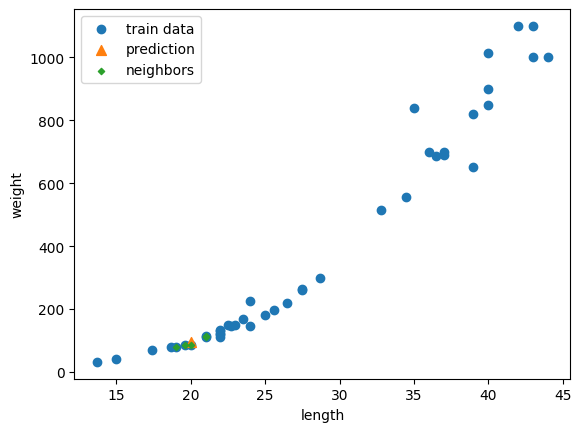

In [30]:
#시각화
plt.scatter(train_input, train_target, label="train data")
plt.scatter(20, knr.predict([[20]]), marker='^', s=50, label="prediction")
plt.scatter(train_input[indexes], train_target[indexes], 
            marker='D', s=10, label="neighbors")
plt.xlabel("length")
plt.ylabel("weight")
plt.legend()
plt.show()
